In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.text as text
from pylab import *
import netCDF4 as nc
from netCDF4 import Dataset
import matplotlib.mlab as m
import pandas as pd
#import mpl_toolkits.basemap as bm
import random
from scipy.stats import norm
import statistics
import xarray as xr
import Adtools as Adtools
from datetime import datetime
import cartopy.crs as ccrs
import cartopy
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib import gridspec
from scipy import stats
import scipy.stats
from scipy.stats import linregress
from cartopy.util import add_cyclic_point
from mpl_toolkits.basemap import Basemap

import seaborn as sns

In [2]:
dirseas5='/nf1/predict/AWH017_ABID_ASPECT/seas5_7monthfcst/nov/tmin/netcdf/'
dirseas5

'/nf1/predict/AWH017_ABID_ASPECT/seas5_7monthfcst/nov/tmin/netcdf/'

In [5]:
dirfig='/nf1/predict/AWH017_ABID_ASPECT/fig_article_frostdays/'
#dirfig

In [6]:
dirdata_eq='/nf1/predict/AWH017_ABID_ASPECT/equalwgts_merged_data/anomaly/indices/'
#dirdata_eq

In [7]:
dirdata='/nf1/predict/AWH017_ABID_ASPECT/anomalydata/indices/'
#dirdata

In [8]:
dirdata_wgt='/nf1/predict/AWH017_ABID_ASPECT/weighted_merged_data/without_march/anomaly_negzero/indices/'
#dirdata_wgt

In [9]:
oct_fcst_1=xr.open_dataset(dirdata+'oct_anom_mem_index.nc')
#oct_fcst_1

In [10]:
nov_fcst_1=xr.open_dataset(dirdata+'nov_anom_mem_index.nc')
nov_fcst_1=nov_fcst_1.sel(time=slice(datetime(1983,1,1),datetime(2022,12,31)))
#nov_fcst_1

In [11]:
dec_fcst_1=xr.open_dataset(dirdata+'dec_anom_mem_index.nc')
#dec_fcst_1

In [12]:
jan_fcst_1=xr.open_dataset(dirdata+'jan_anom_mem_index.nc')
#jan_fcst_1

In [13]:
feb_fcst_1=xr.open_dataset(dirdata+'feb_anom_mem_index.nc')
feb_fcst_1=feb_fcst_1.sel(time=slice(datetime(1983,1,1),datetime(2022,12,31)))
#feb_fcst_1

In [14]:
mar_fcst_1=xr.open_dataset(dirdata+'mar_anom_mem_index.nc')
mar_fcst_1=mar_fcst_1.sel(time=slice(datetime(1983,1,1),datetime(2022,12,31)))
#mar_fcst_1

In [15]:
aug_fcst_1=xr.open_dataset(dirdata+'aug_anom_mem_index.nc')
#aug_fcst_1

In [16]:
may_fcst_1=xr.open_dataset(dirdata+'mayY1_anom_mem_index.nc')
may_fcst_1=may_fcst_1.sel(time=slice(datetime(1983,1,1),datetime(2022,12,31)))
#may_fcst_1

In [17]:
nov_fcst_y2=xr.open_dataset(dirdata+'nov_y2_anom_mem_index.nc')
#nov_fcst_y2

In [18]:
may_fcst_y2=xr.open_dataset(dirdata+'may_y2_anom_mem_index.nc')
#may_fcst_y2

# ERA5 data

In [19]:
era5_obs=xr.open_dataset(dirdata+'era5_ffdindex_anom_maap_freqts.nc')
#era5_obs

# Merged data

In [20]:
merge0_fcst_1=xr.open_dataset(dirdata_wgt+'merge0_index.nc')
#merge0_fcst_1



In [21]:
merge1_fcst_1=xr.open_dataset(dirdata_wgt+'merge1_index.nc')
#merge1_fcst_1

In [22]:
merge2_fcst_1=xr.open_dataset(dirdata_wgt+'merge2_index.nc')
#merge2_fcst_1

In [23]:
merge3_fcst_1=xr.open_dataset(dirdata_wgt+'merge3_index.nc')
#merge3_fcst_1

In [24]:
merge4_fcst_1=xr.open_dataset(dirdata_wgt+'merge4_index.nc')
#merge4_fcst_1

In [25]:
merge5_fcst_1=xr.open_dataset(dirdata_wgt+'merge5_index.nc')
#merge5_fcst_1

In [26]:
merge6_fcst_1=xr.open_dataset(dirdata_wgt+'merge6_index.nc')
#merge6_fcst_1

In [27]:
merge7_fcst_1=xr.open_dataset(dirdata_wgt+'merge7_index.nc')
#merge7_fcst_1

In [28]:
observations=era5_obs.topo[:-2]
observations

<xarray.DataArray 'topo' (time: 40)> Size: 160B
[40 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 320B 1983-04-30 1984-04-30 ... 2022-04-30

In [31]:
ensmean_mar_fcst_1=mar_fcst_1.fd.mean(dim='member')
ensmean_mar_fcst_1

ensmean_feb_fcst_1=feb_fcst_1.fd.mean(dim='member')
ensmean_feb_fcst_1

ensmean_jan_fcst_1=jan_fcst_1.fd.mean(dim='member')
ensmean_jan_fcst_1

ensmean_dec_fcst_1=dec_fcst_1.fd.mean(dim='member')
ensmean_dec_fcst_1

ensmean_nov_fcst_1=nov_fcst_1.fd.mean(dim='member')
ensmean_nov_fcst_1

ensmean_oct_fcst_1=oct_fcst_1.fd.mean(dim='member')
ensmean_oct_fcst_1

ensmean_aug_fcst_1=aug_fcst_1.fd.mean(dim='member')
ensmean_aug_fcst_1

ensmean_may_fcst_1=may_fcst_1.fd.mean(dim='member')
ensmean_may_fcst_1

ensmean_novY2_fcst_1=nov_fcst_y2.fd.mean(dim='member')
#ensmean_novY2_fcst_1


In [34]:
ensmean_merge7=merge7_fcst_1.fd.mean(dim='member')
ensmean_merge7

ensmean_merge6=merge6_fcst_1.fd.mean(dim='member')
ensmean_merge6

ensmean_merge5=merge5_fcst_1.fd.mean(dim='member')
ensmean_merge5

ensmean_merge4=merge4_fcst_1.fd.mean(dim='member')
ensmean_merge4

ensmean_merge3=merge3_fcst_1.fd.mean(dim='member')
ensmean_merge3

ensmean_merge2=merge2_fcst_1.fd.mean(dim='member')
ensmean_merge2

ensmean_merge1=merge1_fcst_1.fd.mean(dim='member')
ensmean_merge1

ensmean_merge0=merge0_fcst_1.fd.mean(dim='member')
#ensmean_merge0

# RMSE function

In [35]:
def rmse(x,y):
    rmse=np.sqrt(( (x-y)**2 ).mean())
    return rmse

# Calculation

In [37]:
rmse_novY2=rmse(ensmean_novY2_fcst_1, observations)
rmse_novY2

rmse_may=rmse(ensmean_may_fcst_1, observations)
rmse_may

rmse_aug=rmse(ensmean_aug_fcst_1, observations)
rmse_aug

rmse_oct=rmse(ensmean_oct_fcst_1, observations)
rmse_oct

rmse_nov=rmse(ensmean_nov_fcst_1, observations)
rmse_nov

rmse_dec=rmse(ensmean_dec_fcst_1, observations)
rmse_dec

rmse_jan=rmse(ensmean_jan_fcst_1, observations)
rmse_jan

rmse_feb=rmse(ensmean_feb_fcst_1, observations)
rmse_feb

rmse_mar=rmse(ensmean_mar_fcst_1, observations)
#rmse_mar, rmse_feb

In [39]:
rmse_merge0=rmse(ensmean_merge0, observations)
rmse_merge0

rmse_merge1=rmse(ensmean_merge1, observations)
rmse_merge1

rmse_merge2=rmse(ensmean_merge2, observations)
rmse_merge2

rmse_merge3=rmse(ensmean_merge3, observations)
rmse_merge3

rmse_merge4=rmse(ensmean_merge4, observations)
rmse_merge4

rmse_merge5=rmse(ensmean_merge5, observations)
rmse_merge5

rmse_merge6=rmse(ensmean_merge6, observations)
rmse_merge6

rmse_merge7=rmse(ensmean_merge7, observations)
#rmse_merge7

In [40]:
rmse_merge=np.array([rmse_merge0,rmse_merge1,rmse_merge2,rmse_merge3,rmse_merge4,rmse_merge5,rmse_merge6,rmse_merge7])
#rmse_merge

In [41]:
rmse_startdate=np.array([rmse_novY2,rmse_may,rmse_aug,rmse_oct,rmse_nov,rmse_dec,rmse_jan,rmse_feb,rmse_mar])
#rmse_startdate

In [42]:
diff_rmse=array([rmse_startdate[:-1]])- array([rmse_merge])
#diff_rmse

In [43]:
#percentage_change_rmse=1- (array([rmse_startdate[:-1]])/array([rmse_merge]))
#percentage_change_rmse*100a

percentage_change_rmse= 1- array([rmse_startdate[:-1]])/array([rmse_merge])
#percentage_change_rmse*100

In [45]:
# this will be run for each forecast start date separately. Then you will have upper and lower bound estimates.
nboot = 10000
diffs = []

for _ in range(nboot):
    idx = np.random.choice(len(observations), len(observations), replace=True)

    rmse_A = np.sqrt(np.mean((ensmean_feb_fcst_1[idx]- observations[idx])**2))
    rmse_B = np.sqrt(np.mean((ensmean_merge7[idx]- observations[idx])**2))

    diffs.append(rmse_A - rmse_B)

ci = np.percentile(diffs, [2.5, 97.5])

#print(ci)

In [46]:
#rmse_lowci=[-0.01963293, -0.01457118, 0.14489741, 0.01237685, -0.07583426, 0.13349512, 0.31487632, 0.15842365]

In [47]:
#rmse_highci=[0.46963863  ,0.67015016,0.93912138, 0.72989943, 0.55065639, 0.73765289, 0.68265481, 0.7639608]

/tmp/user/27683/ipykernel_2759610/1706233558.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), rotation=90)


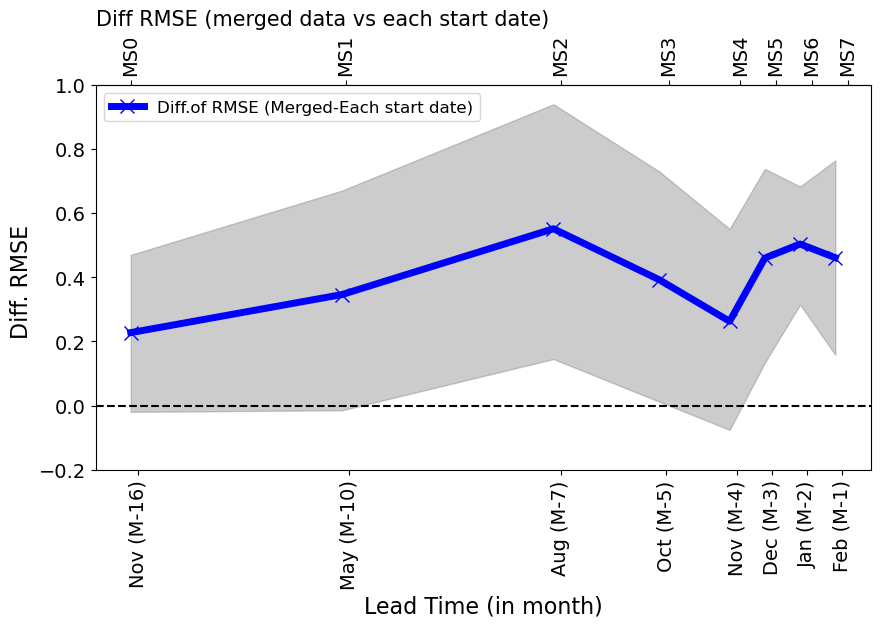

In [136]:
f,ax = plt.subplots(1,1,figsize=[10,5])
#ax2 = ax.twinx()

#ax2 = ax.twinx()
leadtime=np.arange(10)
ftz=14

ci=0.05
ax.set_ylim([-0.2,1])

ax.xaxis.set_tick_params(labelsize=14)
ax.yaxis.set_tick_params(labelsize=14)

ax.set_xticklabels(ax.get_xticks(), rotation=90)
#ax.bar(leadtime, ensiz1,color='gray',label='Ensemble size',linestyle='solid',width=0.4)

ax.set_xticks(leadtime2[:-1]+0.2)

#ax.set_xticklabels( ('May (M-22)','Nov (M-16)','May (M-10)', 'Aug (M-7)','Oct (M-5)','Nov (M-4)','Dec (M-3)','Jan (M-2)','Feb (M-1)','Mar (M-0)' ))
ax.set_xticklabels( ('Nov (M-16)','May (M-10)', 'Aug (M-7)','Oct (M-5)','Nov (M-4)','Dec (M-3)','Jan (M-2)','Feb (M-1)' ))

#ax.set_xticklabels( ('May (Yr-2)','Nov (Yr-2)','May (Yr-1)', 'Aug (Yr-1)','Oct (Yr-1)','Nov (Yr-1)','Dec (Yr-1)','Jan (Yr-0)','Feb (Yr-0)','Mar (Yr-0)' ))
#

#ax.bar(month1, skillmatrix_maap,color='blue',label='FD_Freq_Skill(March-Apr)',linestyle='solid')
#ax.set_ylabel('RMSE ($^{\circ}$C)', fontsize=16)
ax.set_ylabel('Diff. RMSE ', fontsize=16)
ax.set_xlabel('Lead Time (in month)',fontsize=16)

ax.plot(leadtime2[:-1], diff_rmse[0,:],color='blue',label='Diff.of RMSE (Merged-Each start date)',linestyle='solid',marker='x',markersize=10,linewidth=5)

ax.fill_between(leadtime2[:-1], rmse_lowci,rmse_highci,alpha=0.4,color='grey')#,label='shading_95%')
#
ax.axhline(0,linestyle='dashed',color='black')


ax.legend(fontsize=12,loc='upper left',ncols=1)
#plt.savefig(dirfig+"rmse_start_date_rev.png",dpi=300)

def deg2rad(x):
    return x- x * np.pi / 180 


def rad2deg(x):
    return x * 180 / np.pi 
   
secax = ax.secondary_xaxis('top', functions=(deg2rad, rad2deg))

secax.set_xticks(ms2_rmse[:-1])

#secax.set_xticks(ms2[:-1]+0.2)
#secax.set_xticklabels(ax.get_xticks(), rotation=90)

secax.set_xticklabels(ax.get_xticks(), rotation=90)
#secax.set_xticklabels( ('MayY2','MS0','MS1', 'MS2','MS3','MS4','MS5','MS6','MS7','MS8' ))
secax.set_xticklabels( ('MS0','MS1', 'MS2','MS3','MS4','MS5','MS6','MS7' ))
secax.xaxis.set_tick_params(labelsize=14)


ax.set_title('Diff RMSE (merged data vs each start date)',fontsize=15, loc='left')


plt.savefig(dirfig+"FigureS3_rmse_diff_merged_eachdate.png",dpi=300,bbox_inches='tight')

In [54]:
# CRPSS is estimated separetely. Here using values for plotting

In [51]:
crps_eachdate=[1.51498753, 1.54857541, 1.59306969, 1.56932102, 1.46680287,1.54952407, 1.56947164, 1.54162808, 1.44771232]
crps_eachdate

crps_eachdate_1=np.round(crps_eachdate,decimals=2)
#crps_eachdate_1

In [52]:
crps_merge_equalweighted=[1.50851429,1.46183949,1.44280636,1.44616964,1.43710053,1.44023104,1.44023104,1.45227669]

#crps_merge_equalweighted_1 = [ '%.2f' % elem for elem in crps_merge_equalweighted ]
#crps_merge_equalweighted_1

crps_merge_equalweighted_1=np.round(crps_merge_equalweighted,decimals=2)
#crps_merge_equalweighted_1

In [53]:
crps_merge_weighted=[1.10045116,1.07870417,1.09231259,1.1077408,1.09946632,1.10881207,1.10881207,1.13093813]
crps_merge_weighted

crps_merge_weighted_1=np.round(crps_merge_weighted,decimals=2)
#crps_merge_weighted_1

In [ ]:
f,ax = plt.subplots(1,1,figsize=[10,5])
#ax2 = ax.twinx()

leadtime=np.arange(8)
ftz=14

ci=0.05
ax.set_ylim([0,3])

ax.xaxis.set_tick_params(labelsize=10)
ax.yaxis.set_tick_params(labelsize=15)
#ax2.yaxis.set_tick_params(labelsize=15)

#ax.bar(leadtime, ensiz1,color='gray',label='Ensemble size',linestyle='solid',width=0.4)

ax.set_xticks(leadtime)
ax.set_xticklabels( ('Nov (Yr-2)/M0','M1', 'M2','M3','M4','M5','M6','M7' ))
#

#ax.bar(month1, skillmatrix_maap,color='blue',label='FD_Freq_Skill(March-Apr)',linestyle='solid')
#ax.set_ylabel('RMSE ($^{\circ}$C)', fontsize=16)
#ax.set_ylabel('RMSE ', fontsize=16)
ax.set_xlabel('Lead Time',fontsize=16)

#ax2.set_ylim([0, 0.7])
ax.bar(leadtime,rmse_merge,color='red',label='RMSE (Mar-Apr)',linestyle='solid',width=0.4)

ax.axhline(np.mean(rmse_merge),linestyle='dashed',color='gray',label='mean_rmse')

ax.legend(fontsize=10,loc='upper center',ncols=2)
#plt.savefig(dirfig+"rmse_start_date_rev.png",dpi=300)

#plt.savefig(dirfig+"rmse_merged_data_rev_13may.png",dpi=300)

In [123]:
diff_rmse.shape

(1, 8)

In [56]:
# with equal weights

score_feb0=1- (crps_merge_equalweighted_1[7]/crps_eachdate_1[7])


score_jan0=1- (crps_merge_equalweighted_1[6]/crps_eachdate_1[6])


score_dec0=1- (crps_merge_equalweighted_1[5]/crps_eachdate_1[5])


score_nov0=1- (crps_merge_equalweighted_1[4]/crps_eachdate_1[4])



score_oct0=1- (crps_merge_equalweighted_1[3]/crps_eachdate_1[3])


score_aug0=1- (crps_merge_equalweighted_1[2]/crps_eachdate_1[2])

score_mayY10=1- (crps_merge_equalweighted_1[1]/crps_eachdate_1[1])


score_novY20=1- (crps_merge_equalweighted_1[0]/crps_eachdate_1[0])


In [58]:
score_equalwgt_rev=array([score_novY20   , score_mayY10, score_aug0,score_oct0, score_nov0,
       score_dec0, score_jan0, score_feb0])
#score_equalwgt_rev*100

In [59]:
score_feb=1- (crps_merge_weighted_1[7]/crps_eachdate_1[7])
score_feb

score_jan=1- (crps_merge_weighted_1[6]/crps_eachdate_1[6])
score_jan

score_dec=1- (crps_merge_weighted_1[5]/crps_eachdate_1[5])
score_dec

score_nov=1- (crps_merge_weighted_1[4]/crps_eachdate_1[4])
score_nov


score_oct=1- (crps_merge_weighted_1[3]/crps_eachdate_1[3])
score_oct

score_aug=1- (crps_merge_weighted_1[2]/crps_eachdate_1[2])
score_aug

score_mayY1=1- (crps_merge_weighted_1[1]/crps_eachdate_1[1])
score_mayY1

score_novY2=1- (crps_merge_weighted_1[0]/crps_eachdate_1[0])
#score_novY2

In [61]:
score_wgt_rev=array([score_novY2   , score_mayY1, score_aug,score_oct, score_nov,
       score_dec, score_jan, score_feb])
#score_wgt_rev*100

In [62]:
max(score_wgt_rev*100), min(score_wgt_rev*100), np.mean(score_wgt_rev*100)

(31.446540880503136, 25.170068027210878, 28.46258836823623)

In [55]:
check_crpss=[0.27362077387160233,
 0.3034218666253382,
 0.3143493817086185,
 0.2941183967373988,
 0.25042950640850836,
 0.2844078735075831,
 0.29351309677789306,
 0.2664015775612667] 
#check_crpss

In [63]:
rmse_startdate

array([1.76223998, 1.86336429, 2.07473352, 1.92317268, 1.79331033,
       1.99435361, 2.03803727, 2.0026847 , 1.65281523])

In [64]:
diff_rmse=(rmse_startdate [:-1]-  rmse_merge)#/rmse_startdate[1:9])
#diff_rmse*100

In [67]:
# Final revised figure

#ms2_rmse

ms=np.arange(16)
ms2=np.array([ms[0],ms[6],ms[9],ms[11],ms[12],ms[13],ms[14],ms[15]])
#ms2

/tmp/user/27683/ipykernel_2759610/251694937.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticks(), rotation=90)


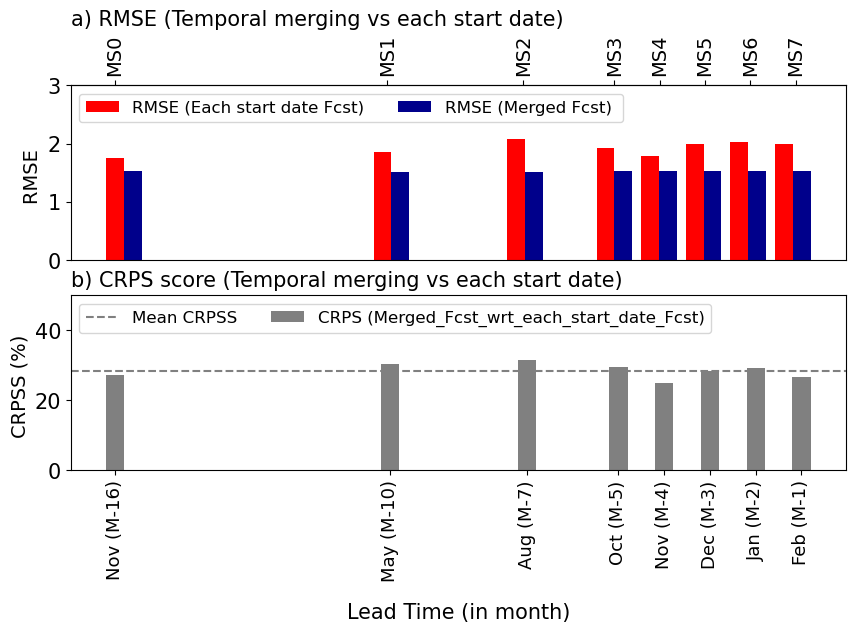

In [162]:
f,ax = plt.subplots(2,1,figsize=[10,5])

ftz=14

ci=0.05
ax[0].set_ylim([0,3])

ax[0].xaxis.set_tick_params(labelsize=13)
ax[0].yaxis.set_tick_params(labelsize=15)
ax[0].set_xticklabels(ax[0].get_xticks(), rotation=90)
ax[0].set_xticks([])
#ax[0].set_xticks(leadtime5[:-1]+0.2)
#ax[0].set_xticks(leadtime5)
#ax[0].set_xticklabels( ('Nov (M-16)','May (M-10)', 'Aug (M-7)','Oct (M-5)','Nov (M-4)','Dec (M-3)','Jan (M-2)','Feb (M-1)' ))

ax[0].set_ylabel('RMSE ', fontsize=14)
#ax[0].set_xlabel('Lead Time (in month)',fontsize=16)

ax[0].bar(leadtime4[0],rmse_startdate[0],color='red',width=0.4,label='RMSE (Each start date Fcst)')

ax[0].bar(leadtime4[6],rmse_startdate[1],color='red',width=0.4)
ax[0].bar(leadtime4[9],rmse_startdate[2],color='red',width=0.4)

ax[0].bar(leadtime4[11],rmse_startdate[3],color='red',width=0.4)
ax[0].bar(leadtime4[12],rmse_startdate[4],color='red',width=0.4)
ax[0].bar(leadtime4[13],rmse_startdate[5],color='red',width=0.4)
ax[0].bar(leadtime4[14],rmse_startdate[6],color='red',width=0.4)
ax[0].bar(leadtime4[15],rmse_startdate[7],color='red',width=0.4)
#ax.bar(leadtime4[16],rmse_startdate_1[8],color='red',width=0.4)



#ax.bar(leadtime1[6]+0.4,rmse_startdate_merge[0],color='darkblue',width=0.4,label='RMSE (Mar-Apr) based on Merged data ')

ax[0].bar(leadtime4[0]+0.4,rmse_merge[0],color='darkblue',width=0.4,label='RMSE (Merged Fcst) ')
ax[0].bar(leadtime4[6]+0.4,rmse_merge[1],color='darkblue',width=0.4)

ax[0].bar(leadtime4[9]+0.4,rmse_merge[2],color='darkblue',width=0.4)
ax[0].bar(leadtime4[11]+0.4,rmse_merge[3],color='darkblue',width=0.4)
ax[0].bar(leadtime4[12]+0.4,rmse_merge[4],color='darkblue',width=0.4)
ax[0].bar(leadtime4[13]+0.4,rmse_merge[5],color='darkblue',width=0.4)
ax[0].bar(leadtime4[14]+0.4,rmse_merge[6],color='darkblue',width=0.4)
ax[0].bar(leadtime4[15]+0.4,rmse_merge[7],color='darkblue',width=0.4)

ax[0].legend(fontsize=12,loc='upper left',ncols=2)



def deg2rad(x):
    return x- x * np.pi / 180 


def rad2deg(x):
    return x * 180 / np.pi 
   
secax = ax[0].secondary_xaxis('top', functions=(deg2rad, rad2deg))

secax.set_xticks(ms2[:])

#secax.set_xticks(ms2[:-1]+0.2)
#secax.set_xticklabels(ax.get_xticks(), rotation=90)

secax.set_xticklabels(ax[0].get_xticks(), rotation=90)
#secax.set_xticklabels( ('MayY2','MS0','MS1', 'MS2','MS3','MS4','MS5','MS6','MS7','MS8' ))
secax.set_xticklabels( ('MS0','MS1', 'MS2','MS3','MS4','MS5','MS6','MS7' ))
secax.xaxis.set_tick_params(labelsize=14)

ax[0].set_title('a) RMSE (Temporal merging vs each start date)',fontsize=15, loc='left')

#######

#ax.set_ylim([-15, 15])
ax[1].set_ylim([0, 50])
#ax[1].set_xticks(leadtime5)
#ax.bar(n200,score_matrix*-1, width=0.4,color='blue',label='Final_merged_wrt_each_start_date')
ax[1].bar(leadtime4[0],score_wgt_rev[0]*100, width=0.4,color='gray',label='CRPS (Merged_Fcst_wrt_each_start_date_Fcst)')
ax[1].bar(leadtime4[6],score_wgt_rev[1]*100, width=0.4,color='gray')
ax[1].bar(leadtime4[9],score_wgt_rev[2]*100, width=0.4,color='gray')
ax[1].bar(leadtime4[11],score_wgt_rev[3]*100, width=0.4,color='gray')
ax[1].bar(leadtime4[12],score_wgt_rev[4]*100, width=0.4,color='gray')
ax[1].bar(leadtime4[13],score_wgt_rev[5]*100, width=0.4,color='gray')
ax[1].bar(leadtime4[14],score_wgt_rev[6]*100, width=0.4,color='gray')
ax[1].bar(leadtime4[15],score_wgt_rev[7]*100, width=0.4,color='gray')
#ax.bar(leadtime4[16],score_matrixn[8], width=0.4,color='gray')
#ax.bar(n200,score_matrixe, width=0.4,color='blue',label='CRPS (Merged_data(-1)_vs_each_start_date)')

ax[1].set_xticks(leadtime5)
ax[1].set_xticklabels(ax[1].get_xticks(), rotation=90)
ax[1].set_xticklabels( ('Nov (M-16)','May (M-10)', 'Aug (M-7)','Oct (M-5)','Nov (M-4)','Dec (M-3)','Jan (M-2)','Feb (M-1)' ))

#ax.set_xticks(leadtime4)
ax[1].xaxis.set_tick_params(labelsize=13)
ax[1].yaxis.set_tick_params(labelsize=15)


#def deg2rad(x):
#    return x- x * np.pi / 180 


#def rad2deg(x):
#    return x * 180 / np.pi 
   
#secax = ax.secondary_xaxis('top', functions=(deg2rad, rad2deg))

#secax.set_xticks(ms2[:-1])
#secax.set_xticklabels(ax[1].get_xticks(), rotation=90)
#secax.set_xticklabels( ('MS0','MS1', 'MS2','MS3','MS4','MS5','MS6','MS7' ))
#secax.xaxis.set_tick_params(labelsize=13)


################################3
#ax2.set_xticks(leadtime[1:10])

#secax = ax.secondary_xaxis('top', functions=(deg2rad, rad2deg))

#kk=np.arange(0,9,1)
#secax.set_xticklabels( ('','M0','M2', 'M4','M6','M8' ))
##################################

ax[1].set_ylabel('CRPSS (%) ', fontsize=14)
ax[1].set_xlabel('Lead Time (in month)',fontsize=15,labelpad=15)
ax[1].set_title('b) CRPS score (Temporal merging vs each start date)',fontsize=15, loc='left')

ax[1].axhline(np.mean(score_wgt_rev*100),linestyle='dashed',color='gray',label='Mean CRPSS')

ax[1].legend(fontsize=12,ncols=2,loc='upper left')

plt.savefig(dirfig+"Figure3_revised_rmse_crps_final.png",dpi=300,bbox_inches='tight')